In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 
import os 

In [2]:
train_dir = "E:\\6CS012\\Week 4 - Multi Layer Neural Network\\DevanagariHandwrittenDigitDataset\\Train\\"
test_dir  = "E:\\6CS012\\Week 4 - Multi Layer Neural Network\\DevanagariHandwrittenDigitDataset\\Test\\"
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images, labels = [], []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")        # grayscale
            img = img.resize((img_width, img_height))       # resize to 28x28
            img = np.array(img) / 255.0                     # normalize to [0,1]
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

# Reshape for Keras: (num_samples, 28, 28, 1)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test  = x_test.reshape(-1,  img_height, img_width, 1)

In [4]:
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

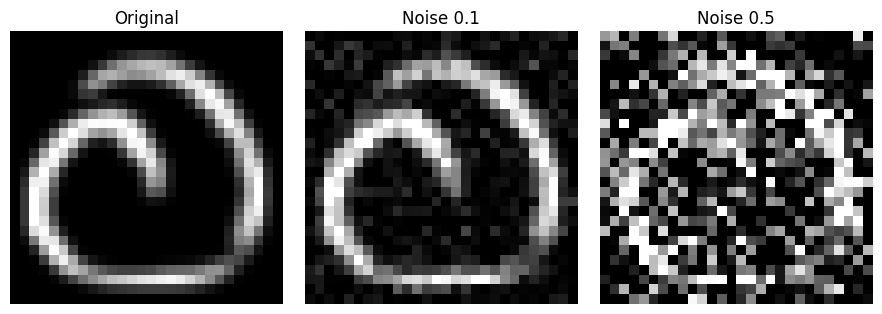

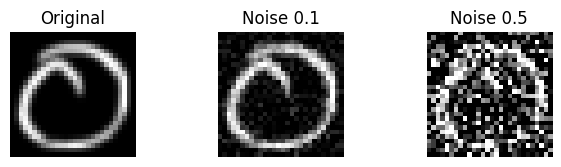

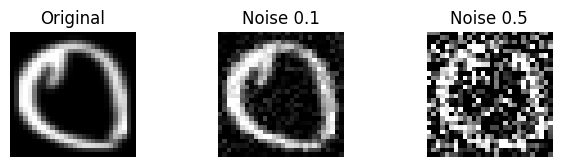

In [5]:
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
# Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
# Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')
    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray'   )
    plt.title("Noise 0.5")
    plt.axis('off'  )
    plt.tight_layout()
    plt.show()

Encoder

In [6]:
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
def build_encoder(input_shape=(28, 28, 1)):
    """
Builds the encoder part of the convolutional autoencoder.
Parameters:
input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
Returns:
input_img (Keras Input): Input layer of the model.
encoded (Keras Tensor): Encoded representation after convolution and pooling.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

Decoder

In [7]:
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    Parameters:
    encoded_input (Keras Tensor): The output from the encoder.
    Returns:
    decoded (Keras Tensor): The reconstructed output after upsampling and
    convolution.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

Complete Autoencoder

In [8]:
from keras.models import Model
from keras.optimizers import Adam
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting encoder and
    decoder.
    Returns:
    autoencoder (Keras Model): Compiled autoencoder model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

Compile the autoencoder

In [9]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.3067 - val_loss: 0.2143
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.2069 - val_loss: 0.2001
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.1979 - val_loss: 0.1949
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1939 - val_loss: 0.1923
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1909 - val_loss: 0.1899
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1891 - val_loss: 0.1873
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1874 - val_loss: 0.1862
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.1860 - val_loss: 0.1854
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.1851 - val_loss: 0.1842
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1843 - val_loss: 0.1839


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


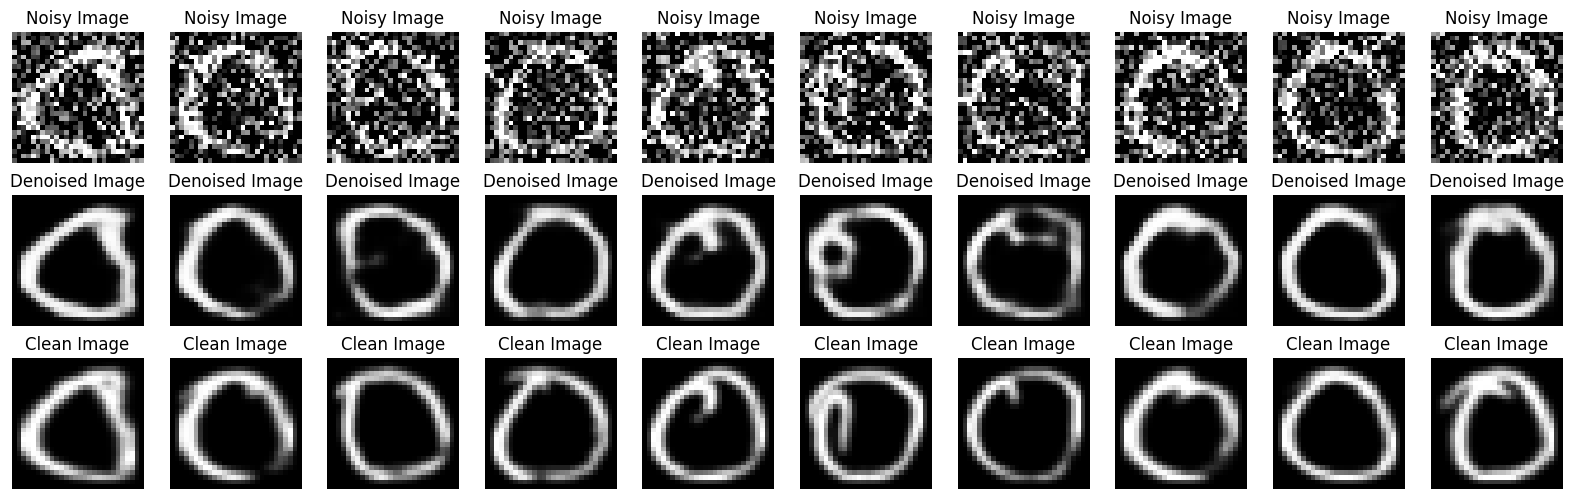

In [12]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)
# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
    # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off'  )
        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off'          )
        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off'              )
    plt.show()
        # Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

In [17]:
from keras.callbacks import TensorBoard

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test),
                callbacks=[TensorBoard(log_dir='logs/autoencoder')])

Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1374 - val_loss: 0.1375
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1375 - val_loss: 0.1374
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1374 - val_loss: 0.1375
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1374 - val_loss: 0.1373
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1373 - val_loss: 0.1372
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1373 - val_loss: 0.1372
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1373 - val_loss: 0.1373
Epoch 8/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.1372 - val_loss: 0.1372
Epoch 9/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.1372 - val_loss: 0.1371
Epoch 10/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.1372 - val_loss: 0.1372
Epoch 11/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.1371 - val_loss: 0.1373
Epoch 12/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 